In [1]:
"""
# 03 · Clasificación con MLP en PyTorch (Digits Dataset)

En este notebook vamos a construir nuestra primera red neuronal para un problema de clasificación.

Usaremos el dataset clásico de "digits" de "scikit-learn", que contiene imágenes de dígitos escritos a mano (0–9).

Cada imagen tiene:

- tamaño: 8x8 píxeles
- entrada: 64 features (flatten)
- salida: 10 clases

## Objetivo

Entrenar una red neuronal (MLP) que pueda clasificar correctamente los dígitos.

## Qué vamos a aprender

- Uso de "Dataset" y "DataLoader"
- Definición de redes neuronales con "nn.Module"
- Clasificación con "CrossEntropyLoss"
- Loop de entrenamiento más realista
- Evaluación con accuracy
- Matriz de confusión
"""

'\n# 03 · Clasificación con MLP en PyTorch (Digits Dataset)\n\nEn este notebook vamos a construir nuestra primera red neuronal para un problema de clasificación.\n\nUsaremos el dataset clásico de "digits" de "scikit-learn", que contiene imágenes de dígitos escritos a mano (0–9).\n\nCada imagen tiene:\n\n- tamaño: 8x8 píxeles\n- entrada: 64 features (flatten)\n- salida: 10 clases\n\n## Objetivo\n\nEntrenar una red neuronal (MLP) que pueda clasificar correctamente los dígitos.\n\n## Qué vamos a aprender\n\n- Uso de "Dataset" y "DataLoader"\n- Definición de redes neuronales con "nn.Module"\n- Clasificación con "CrossEntropyLoss"\n- Loop de entrenamiento más realista\n- Evaluación con accuracy\n- Matriz de confusión\n'

In [2]:
# ------------------------------------------------------------
# 01 · Imports and configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [3]:
"""
## 1. Carga del dataset

El dataset "digits" contiene imágenes 8x8 de dígitos del 0 al 9.

Cada imagen se representa como un vector de 64 valores.
"""
# ------------------------------------------------------------
# 02 · Load dataset
# ------------------------------------------------------------

digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


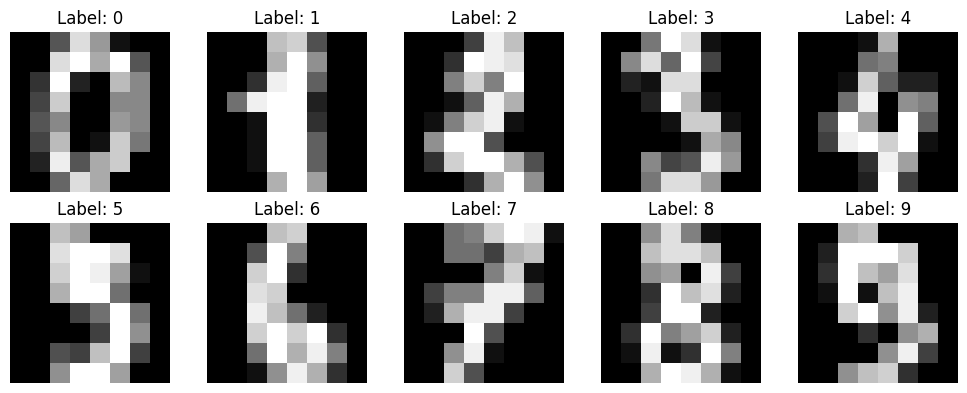

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\digits_samples.png


In [4]:
# ------------------------------------------------------------
# 03 · Visualize some digits
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()

out = FIGURES_DIR / "digits_samples.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [8]:
"""
## 2. Train / Test split

Dividimos el dataset en:

- entrenamiento
- test

para evaluar correctamente el modelo.
"""
# ------------------------------------------------------------
# 04 · Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1437, 64)
Test size: (360, 64)


In [9]:
## 3. Conversión a tensores

#Convertimos los datos a PyTorch.
# ------------------------------------------------------------
# 05 · Convert to tensors
# ------------------------------------------------------------

X_train = torch.from_numpy(X_train)
X_test  = torch.from_numpy(X_test)

y_train = torch.from_numpy(y_train)
y_test  = torch.from_numpy(y_test)

# Move to device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [10]:
"""
## 4. DataLoader

El DataLoader permite:

- dividir en batches
- mezclar datos
- mejorar eficiencia
"""
# ------------------------------------------------------------
# 06 · DataLoader
# ------------------------------------------------------------

from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

In [11]:
"""
## 5. Definición del modelo (MLP)

Vamos a construir una red neuronal simple:

64 → 128 → 64 → 10
"""
# ------------------------------------------------------------
# 07 · Define MLP model
# ------------------------------------------------------------

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

model = MLP().to(device)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [12]:
"""
## 6. Loss y optimizador

Usamos:

- "CrossEntropyLoss" → clasificación
- "Adam" → optimizador moderno
"""
# ------------------------------------------------------------
# 08 · Loss and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
"""
## 7. Loop de entrenamiento

El modelo se entrena por épocas. En cada época:

1. Se toman batches del "DataLoader".
2. Se calculan predicciones.
3. Se calcula la pérdida.
4. Se limpian gradientes previos.
5. Se ejecuta "backward()".
6. Se actualizan los pesos con el optimizador.

Además, vamos a guardar la pérdida promedio por época para visualizar el entrenamiento.
"""

'\n## 7. Loop de entrenamiento\n\nEl modelo se entrena por épocas. En cada época:\n\n1. Se toman batches del "DataLoader".\n2. Se calculan predicciones.\n3. Se calcula la pérdida.\n4. Se limpian gradientes previos.\n5. Se ejecuta "backward()".\n6. Se actualizan los pesos con el optimizador.\n\nAdemás, vamos a guardar la pérdida promedio por época para visualizar el entrenamiento.\n'

In [14]:
# ------------------------------------------------------------
# 09 · Training loop
# ------------------------------------------------------------

n_epochs = 50
train_loss_history = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Forward pass
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1:03d}/{n_epochs}] - Loss: {epoch_loss:.4f}")

Epoch [010/50] - Loss: 0.0208
Epoch [020/50] - Loss: 0.0028
Epoch [030/50] - Loss: 0.0011
Epoch [040/50] - Loss: 0.0006
Epoch [050/50] - Loss: 0.0004


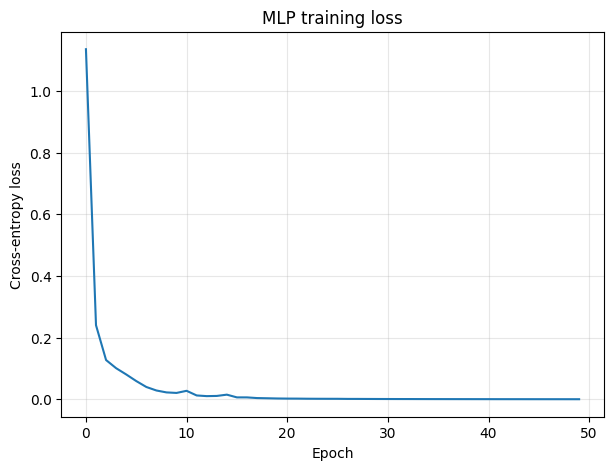

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\mlp_digits_training_loss.png


In [15]:
# ------------------------------------------------------------
# 10 · Plot training loss
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(train_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("MLP training loss")
plt.grid(alpha=0.3)

out = FIGURES_DIR / "mlp_digits_training_loss.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [16]:
"""
## 8. Evaluación del modelo

Para evaluar el modelo usamos "model.eval()" y desactivamos el cálculo de gradientes con "torch.no_grad()".

Esto es importante porque durante evaluación no queremos actualizar pesos ni guardar el grafo computacional.
"""
# ------------------------------------------------------------
# 11 · Evaluate model accuracy
# ------------------------------------------------------------

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_accuracy = correct / total

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9778


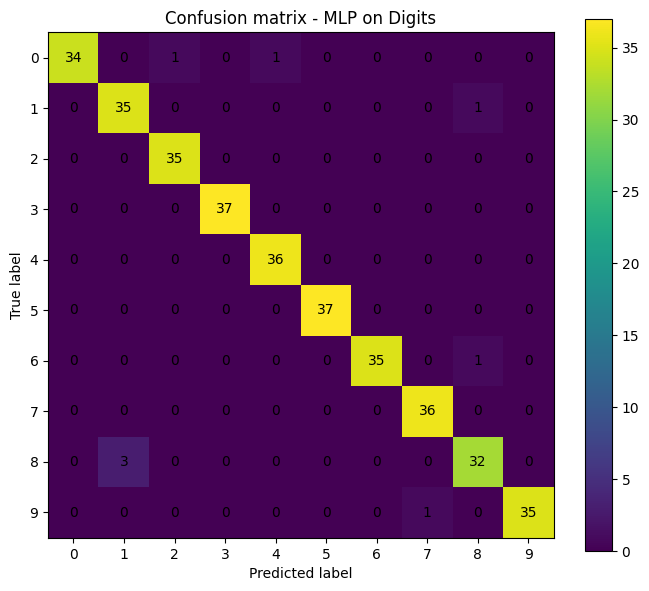

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\mlp_digits_confusion_matrix.png


In [17]:
# ------------------------------------------------------------
# 12 · Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion matrix - MLP on Digits")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

classes = digits.target_names
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

out = FIGURES_DIR / "mlp_digits_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [18]:
# ------------------------------------------------------------
# 13 · Classification report
# ------------------------------------------------------------

report = classification_report(all_labels, all_preds, target_names=[str(c) for c in classes])

print(report)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.92      0.97      0.95        36
           2       0.97      1.00      0.99        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.97      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [19]:
"""
## 9. Interpretación

El modelo alcanza una accuracy alta en el conjunto de test.

Esto indica que incluso una red neuronal multicapa simple puede aprender patrones útiles en imágenes pequeñas.

Sin embargo, este modelo no usa explícitamente la estructura espacial de la imagen. Cada imagen de 8x8 se transforma en un vector de 64 valores.

En problemas de visión por computadora más complejos, las CNNs suelen ser más adecuadas porque aprovechan la estructura local y espacial de las imágenes.
"""

'\n## 9. Interpretación\n\nEl modelo alcanza una accuracy alta en el conjunto de test.\n\nEsto indica que incluso una red neuronal multicapa simple puede aprender patrones útiles en imágenes pequeñas.\n\nSin embargo, este modelo no usa explícitamente la estructura espacial de la imagen. Cada imagen de 8x8 se transforma en un vector de 64 valores.\n\nEn problemas de visión por computadora más complejos, las CNNs suelen ser más adecuadas porque aprovechan la estructura local y espacial de las imágenes.\n'

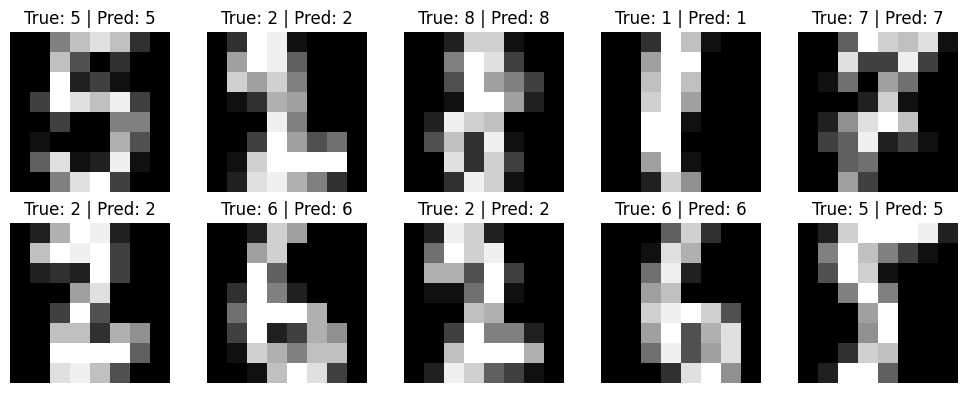

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\mlp_digits_predictions.png


In [20]:
# ------------------------------------------------------------
# 14 · Visualize some predictions
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    sample_logits = model(X_test[:10])
    sample_preds = torch.argmax(sample_logits, dim=1).cpu().numpy()

sample_images = X_test[:10].cpu().numpy()
sample_labels = y_test[:10].cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"True: {sample_labels[i]} | Pred: {sample_preds[i]}")
    ax.axis("off")

plt.tight_layout()

out = FIGURES_DIR / "mlp_digits_predictions.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [21]:
# ------------------------------------------------------------
# 15 · Save trained model
# ------------------------------------------------------------

model_path = MODELS_DIR / "mlp_digits_model.pt"

torch.save(model.state_dict(), model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\models\mlp_digits_model.pt


In [22]:
"""
## 10. Conexión con proyectos reales

Este notebook muestra un pipeline completo de clasificación:

- dataset → preprocessing → DataLoader
- modelo ("nn.Module")
- función de pérdida ("CrossEntropyLoss")
- optimizador ("Adam")
- loop de entrenamiento
- evaluación con métricas reales

Este flujo es directamente aplicable a:

- clasificación de imágenes científicas
- segmentación (con modificaciones)
- análisis de materiales
- tomografía (2D y 3D)

La principal diferencia en problemas reales es:

- mayor tamaño de datos
- uso de GPUs
- arquitecturas más complejas (CNN, U-Net, etc.)

## 11. Resumen

En este notebook:

- Entrenamos una red neuronal multicapa (MLP)
- Usamos DataLoader para manejar batches
- Aplicamos clasificación con "CrossEntropyLoss"
- Evaluamos el modelo con accuracy y matriz de confusión
- Visualizamos predicciones
- Guardamos y cargamos el modelo

Este es el primer modelo no lineal del módulo de PyTorch.

# Conclusión final

El modelo MLP logra una performance alta en un problema de clasificación simple.

Sin embargo, tiene una limitación importante:

No utiliza la estructura espacial de las imágenes.

Esto motiva el uso de:

- Redes Convolucionales (CNN)
- Modelos más avanzados para imágenes 2D
- Modelos 3D para volúmenes tomográficos

En el próximo notebook veremos cómo estructurar correctamente un loop de entrenamiento reutilizable, 
paso clave para escalar a modelos más complejos.
"""

'\n## 10. Conexión con proyectos reales\n\nEste notebook muestra un pipeline completo de clasificación:\n\n- dataset → preprocessing → DataLoader\n- modelo ("nn.Module")\n- función de pérdida ("CrossEntropyLoss")\n- optimizador ("Adam")\n- loop de entrenamiento\n- evaluación con métricas reales\n\nEste flujo es directamente aplicable a:\n\n- clasificación de imágenes científicas\n- segmentación (con modificaciones)\n- análisis de materiales\n- tomografía (2D y 3D)\n\nLa principal diferencia en problemas reales es:\n\n- mayor tamaño de datos\n- uso de GPUs\n- arquitecturas más complejas (CNN, U-Net, etc.)\n\n## 11. Resumen\n\nEn este notebook:\n\n- Entrenamos una red neuronal multicapa (MLP)\n- Usamos DataLoader para manejar batches\n- Aplicamos clasificación con "CrossEntropyLoss"\n- Evaluamos el modelo con accuracy y matriz de confusión\n- Visualizamos predicciones\n- Guardamos y cargamos el modelo\n\nEste es el primer modelo no lineal del módulo de PyTorch.\n\n# Conclusión final\n\nE

In [23]:
# ------------------------------------------------------------
# 17 · End of notebook
# ------------------------------------------------------------

print("Notebook 03 completed successfully.")

Notebook 03 completed successfully.
